<a href="https://colab.research.google.com/github/luisrodriguezh-crypto/Clasificaci-n-Estelar/blob/main/A2_2_LDA_%C3%81rboles_Decisi%C3%B3n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## A2.2 LDA y Árboles de Decisión

1.   Elemento de la lista
2.   Elemento de la lista


### Dataset: Stellar Classification — SDSS17
**Clasificación de Estrellas, Galaxias y Quásares**

---
##**Introduccion**:
<p>
  ¿Alguna vez te has preguntado cómo está conformado el universo? Pues aunque no lo creas, el universo empezó a construirse gracias a algo que muy posiblemente no tenía mucho que ver con él durante esa época: <code>π</code>, una simple constante que nos servía para relacionar el diámetro con la circunferencia, y que ahora nos ayuda a modelar todo el cosmos. Porque para sorpresa de todos, podemos ver las estrellas como <strong>enormes esferas capaces de dar energía por eones</strong>, las galaxias como <strong>discos giratorios gobernados por ecuaciones circulares</strong>, y los quásares como <strong>torbellinos de materia describiendo espirales perfectas hacia un punto de no retorno</strong>. Pero, ¿qué tienen que ver estos tres eventos que por su simple nombre parecen cosas totalmente distintas? Pues bien, eso es exactamente lo que explicaremos.
</p>

<p>
  El universo observable es, en esencia, un caos de puntos de luz gobernado por matemáticas elegantes, y distinguir si cada uno de esos puntos es una <b>estrella solitaria</b>, una <b>galaxia entera</b> con cientos de miles de millones de estrellas, o un <b>quásar</b> &mdash; un agujero negro supermasivo devorando materia con una eficiencia energética hasta <strong>32 veces superior</strong> a la fusión nuclear que alimenta al Sol &mdash; es uno de los problemas más fundamentales y apasionantes de la astronomía moderna. Según
  <a href="https://doi.org/10.3847/1538-4365/ac4414" target="_blank">Abdurro'uf et al. (2022)</a>,
  la clasificación de galaxias, quásares y estrellas es uno de los esquemas más fundamentales en astronomía, y las características espectrales permiten a los astrónomos extraer información sobre los <em>elementos, temperatura, densidad y campo magnético</em> de cada objeto.
</p>

<p>
  Lo que hace este problema verdaderamente fascinante &mdash; y brutalmente difícil &mdash; es que los tres tipos de objetos comparten el mismo <strong>&ldquo;disfraz&rdquo;</strong>: un simple punto de luz en el cielo. El término <code>quásar</code> surgió como contracción de <em>&ldquo;fuente de radio cuasi-estelar&rdquo;</em>, porque cuando se identificaban en imágenes fotográficas se parecían a débiles puntos de luz similares a estrellas
  <a href="https://science.nasa.gov/mission/hubble/science/science-behind-the-discoveries/hubble-quasars/" target="_blank">(NASA — Hubble Quasars, 2025)</a>
  <a href="https://science.nasa.gov/mission/webb/science-overview/science-explainers/what-are-active-galactic-nuclei/" target="_blank">(NASA — What Are Active Galactic Nuclei?, 2025)</a>.
  Es decir, un quásar a <strong>13 mil millones de años luz</strong> y una estrella a <strong>500 años luz</strong> pueden verse idénticos en el cielo nocturno. Y en el espacio de colores ópticos de cinco bandas del SDSS &mdash; exactamente las variables <code>u</code>, <code>g</code>, <code>r</code>, <code>i</code>, <code>z</code> que usamos en este análisis &mdash; los quásares y las estrellas se solapan en su distribución, causando que muchos quásares sean sistemáticamente omitidos en los catálogos
  <a href="https://www.aanda.org/articles/aa/full_html/2020/04/aa36977-19/aa36977-19.html" target="_blank">(Clarke et al., 2020)</a>.
</p>

<p>
  La magnitud del reto es tal que, según
  <a href="https://www.aanda.org/articles/aa/full_html/2020/04/aa36977-19/aa36977-19.html" target="_blank">Clarke et al. (2020)</a>,
  al aplicar un modelo de machine learning a <strong>111 millones de fuentes</strong> del SDSS sin espectros, solo el <strong>15%</strong> de los quásares y el <strong>13%</strong> de las galaxias alcanzaron una probabilidad de clasificación mayor a <code>0.99</code>, mientras que las estrellas lo lograron en un <strong>70%</strong> de los casos. Los quásares resultan particularmente escurridizos porque, como señalan
  <a href="https://academic.oup.com/mnras/article/496/2/2216/5851791" target="_blank">Logan &amp; Fotopoulou (2020)</a>,
  comenzaron a formarse en las etapas más tempranas del universo y su luz electromagnética, que viaja durante <strong>miles de millones de años</strong>, es una ventana única para entender la historia y el pasado del cosmos, siendo además herramienta clave para estudiar la evolución de galaxias y el gas intergaláctico.
</p>

<p>
  Todo lo anterior convierte al dataset
  <a href="https://www.kaggle.com/datasets/fedesoriano/stellar-classification-dataset-sdss17" target="_blank"><strong>SDSS DR17</strong></a>
  &mdash; cuya documentación oficial puede consultarse en
  <a href="https://www.sdss4.org/dr17/" target="_blank">sdss4.org/dr17</a>
  &mdash; en mucho más que un ejercicio académico: es una réplica directa del problema que enfrentan los astrónomos reales cada vez que apuntan un telescopio al cielo, y que proyectos como el
  <a href="https://www.lsst.org" target="_blank">Large Synoptic Survey Telescope (LSST)</a>
  y el
  <a href="https://www.skatelescope.org" target="_blank">Square Kilometre Array (SKA)</a>
  deberán resolver automáticamente para los <strong>miles de millones de objetos</strong> que catalogarán en las próximas décadas.
</p>




## 0. Importación de Librerías

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Modelos
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Partición y validación
from sklearn.model_selection import StratifiedShuffleSplit, KFold, cross_val_score

# Métricas
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report,
                              ConfusionMatrixDisplay)



<h2>Inciso 1: Definición del Problema y Partición de Datos</h2>

<h3>Descripción del Dataset</h3>

<p>
  El dataset utilizado proviene del <strong>Sloan Digital Sky Survey Data Release 17 (SDSS DR17)</strong>,
  publicado por <a href="https://www.kaggle.com/fedesoriano/stellar-classification-dataset-sdss17" target="_blank">fedesoriano (2022)</a>
  en Kaggle y respaldado por la publicación oficial
  <a href="https://arxiv.org/abs/2112.02026" target="_blank">Abdurro'uf et al. (2022), arXiv:2112.02026</a>.
  Contiene <strong>100,000 observaciones</strong> del espacio, cada una descrita por 17 variables
  de tipo espectral, fotométrico e instrumental, clasificadas en tres tipos de objetos celestes:
   <strong>GALAXY</strong>, <strong>STAR</strong> y
   <strong>QSO</strong>  como variable de salida.
</p>

<p>
  Gracias a la literatura, es decir, a estudios previos, podemos despreciar ciertas variables
  del dataset y empezar directamente con las más relevantes. Variables como <code>obj_ID</code>,
  <code>alpha</code>, <code>delta</code>, <code>run_ID</code>, <code>rerun_ID</code>,
  <code>cam_col</code>, <code>field_ID</code>, <code>spec_obj_ID</code>, <code>plate</code>,
  <code>MJD</code> y <code>fiber_ID</code> corresponden a identificadores y metadatos técnicos
  que, como señalan <a href="https://www.aanda.org/articles/aa/full_html/2020/04/aa36977-19/aa36977-19.html" target="_blank">Clarke et al. (2020)</a>,
  no aportan información discriminante para la clasificación de objetos celestes.
  Las variables que entran directamente al modelo son:
</p>

<table border="1" cellpadding="6" cellspacing="0">
  <thead>
    <tr>
      <th>Variable</th>
      <th>Descripción</th>
      <th>Tipo</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td><code>u</code></td>
      <td>Filtro ultravioleta del sistema fotométrico</td>
      <td>Numérica continua</td>
    </tr>
    <tr>
      <td><code>g</code></td>
      <td>Filtro verde del sistema fotométrico</td>
      <td>Numérica continua</td>
    </tr>
    <tr>
      <td><code>r</code></td>
      <td>Filtro rojo del sistema fotométrico</td>
      <td>Numérica continua</td>
    </tr>
    <tr>
      <td><code>i</code></td>
      <td>Filtro infrarrojo cercano del sistema fotométrico</td>
      <td>Numérica continua</td>
    </tr>
    <tr>
      <td><code>z</code></td>
      <td>Filtro infrarrojo del sistema fotométrico</td>
      <td>Numérica continua</td>
    </tr>
    <tr>
      <td><code>log_redshift</code></td>
      <td>Transformación <code>log1p</code> del corrimiento al rojo — corrige su distribución
      log-normal para cumplir los supuestos del LDA</td>
      <td>Numérica continua (transformada)</td>
    </tr>
    <tr>
      <td><code>class</code></td>
      <td><strong>Variable de salida</strong> — GALAXY, STAR o QSO</td>
      <td>Categórica (3 clases)</td>
    </tr>
  </tbody>
</table>

<h3> Variables descartadas del modelo</h3>

<table border="1" cellpadding="6" cellspacing="0">
  <thead>
    <tr>
      <th>#</th>
      <th>Variable</th>
      <th>Descripción</th>
      <th>Razón de descarte</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>1</td>
      <td><code>obj_ID</code></td>
      <td>Identificador único del objeto en el catálogo CAS</td>
      <td>Solo es un folio — no describe el objeto físicamente</td>
    </tr>
    <tr>
      <td>2</td>
      <td><code>alpha</code></td>
      <td>Ángulo de ascensión recta (época J2000)</td>
      <td>Coordenada de posición en el cielo — no dice qué ES el objeto</td>
    </tr>
    <tr>
      <td>3</td>
      <td><code>delta</code></td>
      <td>Ángulo de declinación (época J2000)</td>
      <td>Coordenada de posición en el cielo — no dice qué ES el objeto</td>
    </tr>
    <tr>
      <td>4</td>
      <td><code>run_ID</code></td>
      <td>Número de carrera del escaneo</td>
      <td>Metadato técnico del telescopio</td>
    </tr>
    <tr>
      <td>5</td>
      <td><code>rerun_ID</code></td>
      <td>Número de reprocesamiento de la imagen</td>
      <td>Metadato técnico del telescopio</td>
    </tr>
    <tr>
      <td>6</td>
      <td><code>cam_col</code></td>
      <td>Columna de cámara que identifica la línea de escaneo</td>
      <td>Metadato técnico del telescopio</td>
    </tr>
    <tr>
      <td>7</td>
      <td><code>field_ID</code></td>
      <td>Número de campo del escaneo</td>
      <td>Metadato técnico del telescopio</td>
    </tr>
    <tr>
      <td>8</td>
      <td><code>spec_obj_ID</code></td>
      <td>ID único para objetos espectroscópicos ópticos</td>
      <td>Identificador — no aporta información física</td>
    </tr>
    <tr>
      <td>9</td>
      <td><code>plate</code></td>
      <td>ID de la placa del SDSS</td>
      <td>Metadato técnico del telescopio</td>
    </tr>
    <tr>
      <td>10</td>
      <td><code>MJD</code></td>
      <td>Fecha juliana modificada — cuándo se tomó la observación</td>
      <td>Fecha de captura — irrelevante para clasificar el objeto</td>
    </tr>
    <tr>
      <td>11</td>
      <td><code>fiber_ID</code></td>
      <td>ID de la fibra óptica que apuntó la luz al plano focal</td>
      <td>Metadato técnico del telescopio</td>
    </tr>
  </tbody>
</table>
<p>
  Ojo estas variables <strong>no implica que sean inútiles</strong>
  en un contexto más amplio. <code>alpha</code> y <code>delta</code> son coordenadas y,
  aunque parezcan simples valores angulares, las coordenadas pueden representarse como
  <strong>vectores</strong> — y dos vectores definen un <strong>espacio vectorial</strong>.
  Esto abre una posibilidad muy interesante: utilizando nuestro modelo de clasificación actual
  como base, podríamos asignar una <em>probabilidad de pertenencia a cada clase</em>
  (GALAXY, STAR, QSO) a cada punto de ese espacio vectorial, construyendo esencialmente
  un <strong>mapa probabilístico del cielo</strong>. De esta forma, regiones del espacio
  donde el modelo ha clasificado consistentemente estrellas tendrían una alta probabilidad
  estelar asignada, mientras que zonas perpendiculares al plano galáctico — donde la
  extinción interestelar es menor — tendrían mayor probabilidad de contener quásares
  <a href="https://www.sdss4.org/dr17/" target="_blank">(SDSS, 2022)</a>.
  Este enfoque combina <strong>geometría vectorial</strong> con <strong>inferencia
  probabilística</strong>, y aunque queda fuera del alcance de esta actividad, representa
  una algo realmente emocionante.
</p>
<br>

In [ ]:
# ── Cargar datos ──────────────────────────────────────────
# Asegúrate de tener el archivo en la misma carpeta
# Descarga desde: https://www.kaggle.com/datasets/fedesoriano/stellar-classification-dataset-sdss17
df = pd.read_csv('star_classification.csv')

print('Tamaño original:', df.shape)
df.head()

Tamaño original: (100000, 18)


,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842


<p>
  Ahora como primer paso de preprocesamiento, se eliminaron las variables que no aportan
  información discriminante para la clasificación de objetos celestes. Mediante el
  método <code>drop()</code> de pandas se descartaron los identificadores técnicos
  (<code>obj_ID</code>, <code>spec_obj_ID</code>), las coordenadas espaciales
  (<code>alpha</code>, <code>delta</code>), los metadatos del telescopio
  (<code>run_ID</code>, <code>rerun_ID</code>, <code>cam_col</code>,
  <code>field_ID</code>, <code>plate</code>, <code>fiber_ID</code>) y la fecha
  de observación (<code>MJD</code>), reduciendo el dataset de <strong>18 columnas
  originales</strong> a únicamente las <strong>7 variables relevantes</strong>
  para el modelo: <code>u</code>, <code>g</code>, <code>r</code>, <code>i</code>,
  <code>z</code>, <code>redshift</code> y <code>class</code>.
</p>

In [ ]:
# ── Eliminar columnas no informativas (identificadores y metadatos) ──
drop_cols = ['obj_ID', 'alpha', 'delta', 'run_ID', 'rerun_ID',
             'cam_col', 'field_ID', 'spec_obj_ID', 'plate', 'MJD', 'fiber_ID']
df = df.drop(columns=drop_cols, errors='ignore')

print('Columnas restantes:', df.columns.tolist())
print('\nShape limpio:', df.shape)

Columnas restantes: ['u', 'g', 'r', 'i', 'z', 'class', 'redshift']

Shape limpio: (100000, 7)


<p>
  Algo muy importante a mencionar es que tanto el <strong>LDA</strong> como el
  <strong>árbol de decisión</strong> funcionan de manera similar a una regresión logística
  en el sentido de que <strong>reciben directamente la variable categórica</strong> como
  variable de salida — sklearn maneja internamente las etiquetas de texto sin necesidad
  de transformación adicional. Por lo tanto, aunque podríamos convertir nuestra variable
  <code>class</code> en variables dummy:
</p>

<p>
  $$\text{GALAXY} \rightarrow [1, 0, 0] \quad \text{STAR} \rightarrow [0, 1, 0] \quad
  \text{QSO} \rightarrow [0, 0, 1]$$
</p>

<p>
  Esto <strong>no aportaría ninguna ventaja</strong> para estos modelos — de hecho,
  crearía 3 columnas binarias separadas que ni LDA ni el árbol sabrían interpretar
  correctamente como variable de salida unificada. La variable <code>class</code>
  se mantendra en su forma categórica original:
  <code>'GALAXY'</code>, <code>'STAR'</code> y <code>'QSO'</code>.
</p>

#**Balanceo de clases**:
<p>
  Algo muy importante de nuestros datos es que para que LDA funcione correctamente,
  estos deben cumplir dos reglas fundamentales: <strong>normalidad</strong> en cada clase
  y <strong>homogeneidad de varianzas</strong> entre clases. Por ello, al momento de
  dividir los datos en entrenamiento y prueba, no podemos hacerlo de forma aleatoria —
  necesitamos garantizar que la distribución de clases sea <strong>la misma en ambos
  subconjuntos</strong>. Para esto utilizamos una <strong>partición estratificada</strong>,
  que preserva las proporciones originales del dataset:
</p>

<p>
  $$\text{GALAXY}: 59.4\% \quad \text{STAR}: 21.6\% \quad \text{QSO}: 19.0\%$$
</p>

<p>
  tanto en entrenamiento como en prueba, asegurando así una evaluación justa y representativa
  de ambos modelos.
</p>
<br>

<b>Visualizacio:</b>

Proporciones por clase:
class
GALAXY    0.5944
STAR      0.2159
QSO       0.1896
Name: proportion, dtype: float64


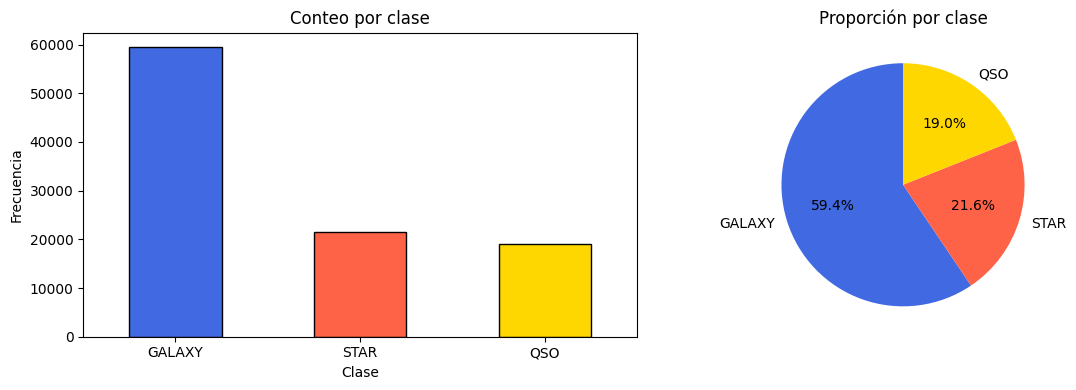

In [ ]:
# ── Balance de clases ──────────────────────────────────────
print('Proporciones por clase:')
print(df['class'].value_counts(normalize=True).round(4))

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ['royalblue', 'tomato', 'gold']

df['class'].value_counts().plot(kind='bar', ax=axes[0], color=colors, edgecolor='black')
axes[0].set_title('Conteo por clase')
axes[0].set_xlabel('Clase')
axes[0].set_ylabel('Frecuencia')
axes[0].tick_params(axis='x', rotation=0)

df['class'].value_counts(normalize=True).plot(kind='pie', ax=axes[1],
    colors=colors, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Proporción por clase')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()


<p>
  Primero, aplicaremos la transformación <code>log1p</code> sobre el <code>redshift</code>
  , recordemos que el redshift de los quásares puede ser extremadamente alto comparado
  con el de las estrellas (que es prácticamente cero), lo que genera una distribución
  muy sesgada. Al aplicar el logaritmo:
</p>

<p>
  $$\text{log_redshift} = \log(1 + \text{redshift})$$
</p>

<p>
  Comprimimos esa escala y acercamos las distribuciones de las tres clases a una forma
  gaussiana — condición necesaria para que LDA funcione correctamente, como discutimos
  en el inciso anterior. Segundo, se definen formalmente las variables de entrada
  <strong>X</strong> — los 5 filtros espectrales más el redshift transformado —
  y la variable de salida <strong>y</strong> — el tipo de objeto celeste.
  Finalmente, se divide el dataset en <strong>80% entrenamiento</strong> y
  <strong>20% prueba</strong> de forma estratificada, es decir, garantizando que
  la proporción de galaxias, estrellas y quásares sea la misma en ambos subconjuntos
  — como si repartiéramos el cielo de forma equitativa entre los dos conjuntos,
  sin que ninguno quede sesgado hacia un tipo de objeto en particular.
</p>

In [ ]:
# ── Transformación de redshift (log-normal → gaussiana) ──
# El redshift sigue una distribución log-normal en astronomía.
# Aplicamos log1p para acercarlo a una distribución normal
df['log_redshift'] = np.log1p(df['redshift'])

# Variables finales para los modelos
FEATURES = ['u', 'g', 'r', 'i', 'z',  'log_redshift']
TARGET   = 'class'

X = df[FEATURES]
y = df[TARGET]

# ── Partición estratificada 80/20 ──────────────────────────
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
for tr_idx, te_idx in sss.split(X, y):
    X_train, X_test = X.iloc[tr_idx], X.iloc[te_idx]
    y_train, y_test = y.iloc[tr_idx], y.iloc[te_idx]


<p>
  Gracias a que preservamos las proporciones originales con <strong>StratifiedShuffleSplit</strong>,
  garantizamos que tanto entrenamiento (80%) como prueba (20%) tengan la misma distribución
  de clases — condición esencial para una evaluación justa de ambos modelos.
</p>

<h2>Inciso 2: Verificación de Supuestos para LDA</h2>

<p>
  Antes de aplicar LDA es obligatorio verificar dos supuestos estadísticos fundamentales —
  si no se cumplen, el modelo puede producir fronteras discriminantes incorrectas y métricas
  engañosas:
</p>

<ul>
  <li>
  <strong>Normalidad:</strong> cada variable debe seguir una distribución gaussiana dentro de cada clase. Se verifica con el test de <em>Shapiro-Wilk</em> un <strong>p-value &gt; 0.05</strong>  indica normalidad, un <strong>p-value &lt; 0.05</strong>  indica una limitación del modelo.
  </li>
  <li>
  <strong>Homocedasticidad:</strong> las tres clases (GALAXY, STAR, QSO) deben compartir la misma matriz de covarianza. Se verifica con el test de <em>Levene</em> bajo la misma regla de p-value. Como anticipamos al analizar el <code>redshift</code>, es probable que este supuesto no se cumpla plenamente — dado que cada tipo de objeto celeste tiene una naturaleza física radicalmente distinta.
  </li>
</ul>

<p>
  Adicionalmente se visualiza la distribución de cada variable por clase,
  complementando el análisis estadístico con evidencia visual directa.
</p>

In [ ]:
# ── Test de Normalidad por clase (Shapiro-Wilk, muestra n=500) ──
print('TEST DE NORMALIDAD — Shapiro-Wilk')
print('='*45)
clases = y_train.unique()

for var in FEATURES:
    print(f'\nVariable: {var}')
    for cls in clases:
        subset = X_train[y_train == cls][var].sample(500, random_state=42)
        stat, p = stats.shapiro(subset)
        flag = 'bueno :)' if p > 0.05 else 'malo :('
        print(f'  {cls:8s}: p={p:.4f} {flag}')


TEST DE NORMALIDAD — Shapiro-Wilk

Variable: u
  QSO     : p=0.0000 malo :(
  STAR    : p=0.0001 malo :(
  GALAXY  : p=0.0000 malo :(

Variable: g
  QSO     : p=0.0024 malo :(
  STAR    : p=0.0012 malo :(
  GALAXY  : p=0.0000 malo :(

Variable: r
  QSO     : p=0.0000 malo :(
  STAR    : p=0.0001 malo :(
  GALAXY  : p=0.0000 malo :(

Variable: i
  QSO     : p=0.0000 malo :(
  STAR    : p=0.0000 malo :(
  GALAXY  : p=0.0000 malo :(

Variable: z
  QSO     : p=0.3712 bueno :)
  STAR    : p=0.0013 malo :(
  GALAXY  : p=0.0000 malo :(

Variable: log_redshift
  QSO     : p=0.0000 malo :(
  STAR    : p=0.0000 malo :(
  GALAXY  : p=0.0000 malo :(


In [ ]:
# ── Test de Homocedasticidad (Levene) ──
print('TEST DE HOMOCEDASTICIDAD — Levene')
print('='*45)
for var in FEATURES:
    groups = [X_train[y_train == cls][var].values for cls in clases]
    stat, p = stats.levene(*groups)
    flag = 'bueno' if p > 0.05 else 'malo :('
    print(f'{var:15s}: p-value = {p:.4f} {flag}')

TEST DE HOMOCEDASTICIDAD — Levene
u              : p-value = 0.0012 malo :(
g              : p-value = 0.0010 malo :(
r              : p-value = 0.0000 malo :(
i              : p-value = 0.0000 malo :(
z              : p-value = 0.0046 malo :(
log_redshift   : p-value = 0.0000 malo :(


<p>
  Los resultados de ambos tests revelan algo que parece no muy motivador ya  que ninguna variable cumple completamente los requisitos de LDA, ni normalidad ni homocedasticidad.Sin embargo, esto no invalida el modelo: con <strong>80,000 observaciones de entrenamiento</strong>, LDA es suficientemente robusto para producir resultados interpretables. Esto claramente tiene una explicacion,galaxias, estrellas y quásares son objetos celestes con naturalezas radicalmente distintas, por lo que sus distribuciones espectrales difieren inevitablemente. Esta evidencia estadística anticipa que el <strong>árbol de decisión</strong>, al no asumir ninguna distribución, podría superar al LDA en esta tarea específica.
</p>

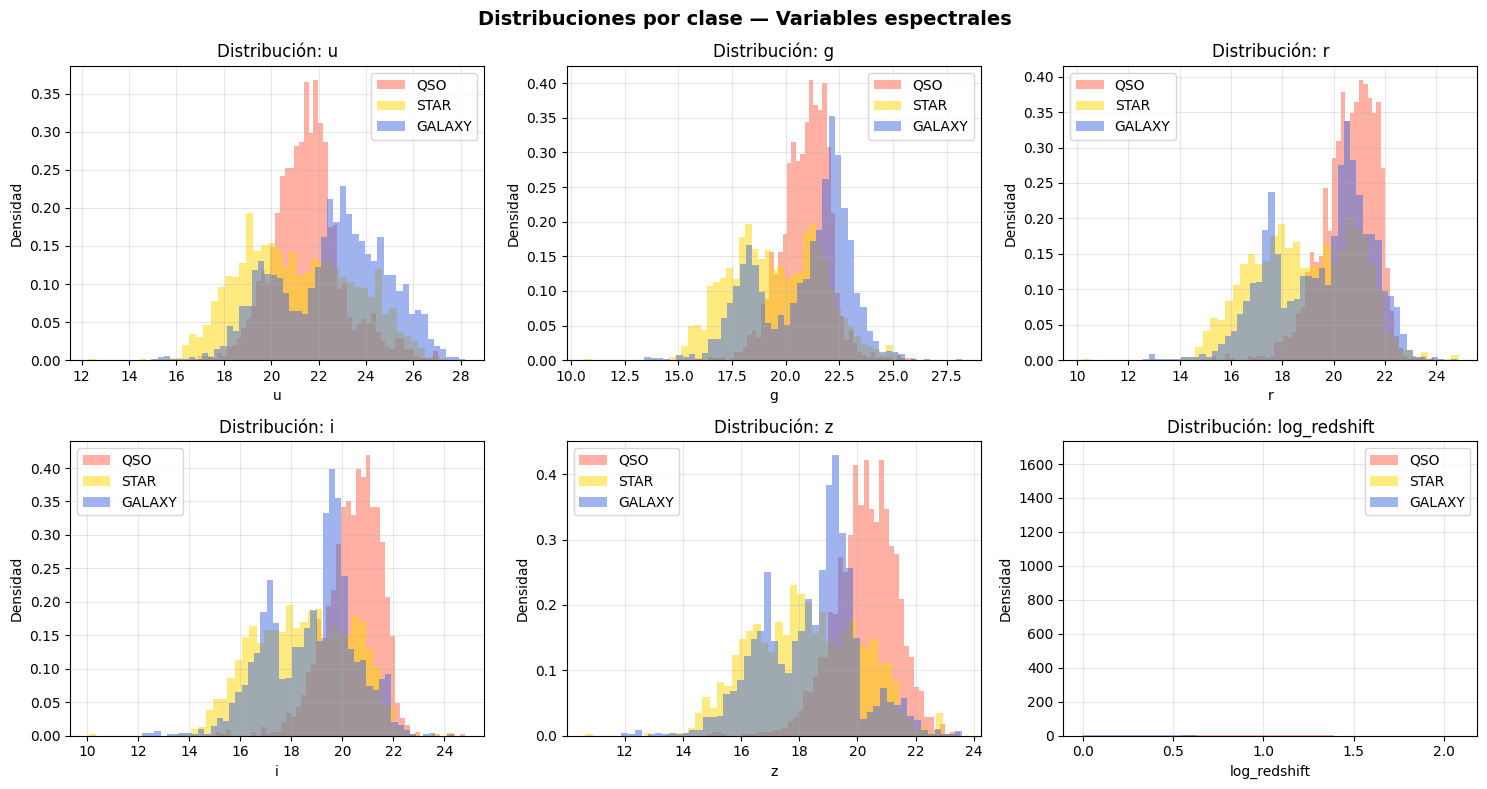

In [ ]:
# ── Visualización de distribuciones por clase ──
colors_map = {'GALAXY': 'royalblue', 'STAR': 'gold', 'QSO': 'tomato'}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, var in enumerate(FEATURES):
    for cls in clases:
        subset = X_train[y_train == cls][var].sample(2000, random_state=42)
        axes[i].hist(subset, bins=50, alpha=0.5,
                     color=colors_map.get(cls, 'gray'),
                     label=cls, density=True)
    axes[i].set_title(f'Distribución: {var}')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Densidad')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Distribuciones por clase — Variables espectrales', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

<h2>Inciso 3: Modelo LDA</h2>

<p>
  La razón por la que elegimos <strong>LDA</strong> como primer modelo es que nuestras
  variables de entrada — los filtros espectrales <code>u</code>, <code>g</code>,
  <code>r</code>, <code>i</code>, <code>z</code> y <code>log_redshift</code> — son
  <strong>numéricas continuas</strong>, y nuestras 3 clases (GALAXY, STAR, QSO) son
  <strong>naturales y bien definidas físicamente</strong>. Si bien los tests de
  Shapiro-Wilk revelaron violaciones de normalidad, esto no invalida el uso de LDA
  gracias al <strong>Teorema Central del Límite</strong>:
</p>

<p>
  $$\text{Si } n \geq 30 \Rightarrow \bar{X} \sim \mathcal{N}\left(\mu, \frac{\sigma^2}{n}\right)$$
</p>

<p>
  Con un mínimo de <strong>15,200 observaciones</strong> en la clase menos representada,
  la aproximación gaussiana es estadísticamente sólida. Respecto a la
  <strong>homocedasticidad</strong>, aunque el test de Levene confirma varianzas distintas
  entre clases, LDA es robusto ante esta violación con muestras grandes
  <a href="https://www.aanda.org/articles/aa/full_html/2020/04/aa36977-19/aa36977-19.html"
  target="_blank">(Clarke et al., 2020)</a>. No obstante, esta diferencia de varianzas
  representa la <strong>limitación principal del modelo</strong> y, como veremos,
  anticipa que el árbol de decisión podría superarlo al no asumir ninguna distribución.
  En esencia, LDA proyecta cada objeto celeste sobre nuevas direcciones que maximizan
  la separación entre clases mediante el criterio de Fisher:
</p>

<p>
  $$J(\mathbf{w}) = \frac{\mathbf{w}^T S_B \mathbf{w}}{\mathbf{w}^T S_W \mathbf{w}}$$
</p>

<p>
  Donde \(S_B\) es la dispersión entre clases y \(S_W\) la dispersión interna.
  El modelo encuentra los pesos óptimos \(w_1 \ldots w_6\) para proyectar cada
  observación sobre <strong>2 funciones discriminantes</strong>:
</p>

<p>
  $$\mathbf{y} = w_1 \cdot u + w_2 \cdot g + w_3 \cdot r + w_4 \cdot i + w_5 \cdot z + w_6 \cdot \log(\text{redshift}+1)$$
</p>

<p>
  Una vez entrenado, el modelo se aplica sobre los datos de entrenamiento y prueba
  para obtener sus coordenadas en el espacio discriminante. Adicionalmente se reporta
  la <strong>varianza explicada</strong> por cada función — es decir, qué porcentaje
  de la separación total entre clases captura <code>LD1</code> y cuánto aporta
  <code>LD2</code>. Si <code>LD1</code> explica, por ejemplo, el 90% de la varianza,
  significa que con esa sola dirección ya se captura la mayor parte de la información
  discriminante entre galaxias, estrellas y quásares.
</p>

In [ ]:
# ── Entrenar LDA ──────────────────────────────────────────
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

# Transformar al espacio discriminante
X_train_lda = lda.transform(X_train)
X_test_lda  = lda.transform(X_test)

print('Varianza explicada por función discriminante:')
for i, v in enumerate(lda.explained_variance_ratio_):
    print(f'  LD{i+1}: {v:.4f}  ({v*100:.2f}%)')
print(f'  Total: {sum(lda.explained_variance_ratio_)*100:.2f}%')

Varianza explicada por función discriminante:
  LD1: 0.8860  (88.60%)
  LD2: 0.1140  (11.40%)
  Total: 100.00%


<p>Aqui unicamente con nuestros datos ya de entrenamiento,visualizamos como se veria:</p>

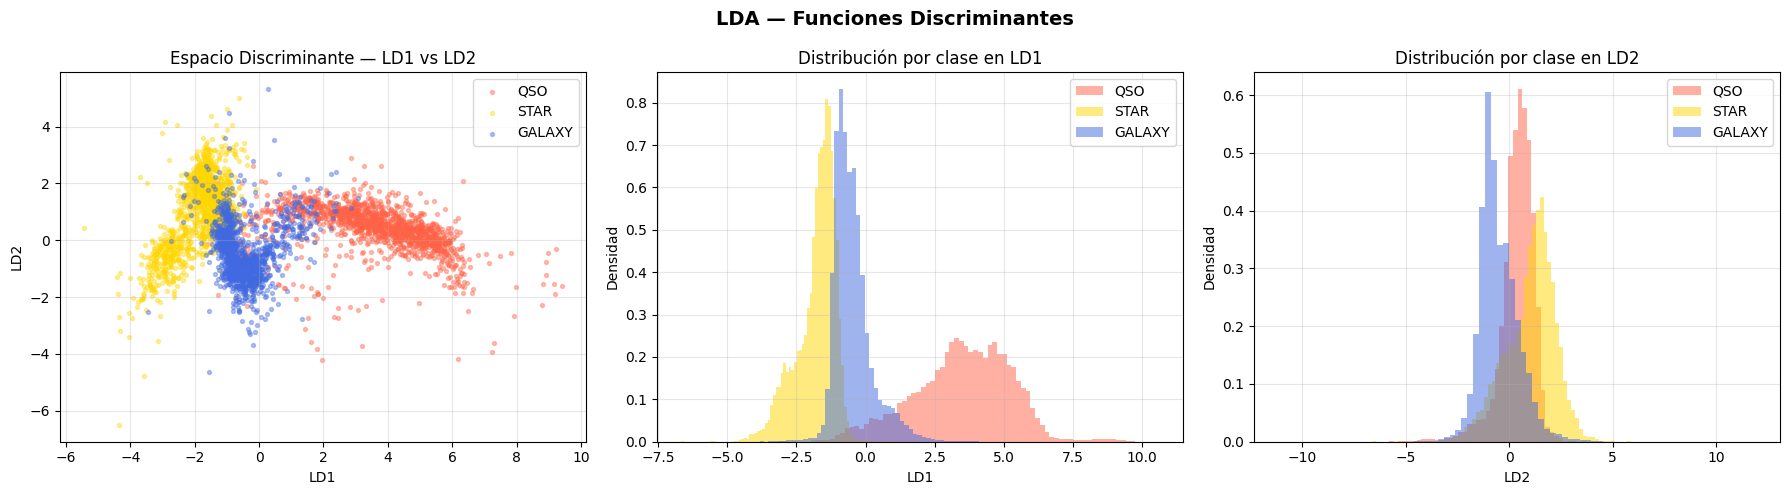

In [ ]:
# ── Visualización del espacio discriminante ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Plot 1: LD1 vs LD2 (scatter) ---
ax = axes[0]
for cls in clases:
    idx = np.where(y_train.values == cls)[0]
    sample = np.random.choice(idx, size=min(1500, len(idx)), replace=False)
    ax.scatter(X_train_lda[sample, 0], X_train_lda[sample, 1],
               c=colors_map.get(cls, 'gray'), label=cls, alpha=0.4, s=8)
ax.set_xlabel('LD1')
ax.set_ylabel('LD2')
ax.set_title('Espacio Discriminante — LD1 vs LD2')
ax.legend()
ax.grid(True, alpha=0.3)

# --- Plot 2: Distribución en LD1 ---
ax = axes[1]
for cls in clases:
    idx = y_train.values == cls
    ax.hist(X_train_lda[idx, 0], bins=80, alpha=0.5,
            color=colors_map.get(cls, 'gray'), label=cls, density=True)
ax.set_xlabel('LD1')
ax.set_ylabel('Densidad')
ax.set_title('Distribución por clase en LD1')
ax.legend()
ax.grid(True, alpha=0.3)

# --- Plot 3: Distribución en LD2 ---
ax = axes[2]
for cls in clases:
    idx = y_train.values == cls
    ax.hist(X_train_lda[idx, 1], bins=80, alpha=0.5,
            color=colors_map.get(cls, 'gray'), label=cls, density=True)
ax.set_xlabel('LD2')
ax.set_ylabel('Densidad')
ax.set_title('Distribución por clase en LD2')
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle('LDA — Funciones Discriminantes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

<h2>Inciso 4: Árbol de Decisión con Poda</h2>

<p>
  El <strong>árbol de decisión</strong> es un modelo que divide recursivamente el espacio
  de variables mediante umbrales, generando reglas del tipo
  <em>"si <code>log_redshift</code> &gt; X entonces QSO"</em>. A diferencia de LDA,
  no asume ninguna distribución en los datos — lo que lo hace naturalmente más flexible
  ante la violación de homocedasticidad detectada en el inciso anterior.
</p>

<p>
  Sin embargo, un árbol sin restricciones tiende a <strong>sobreajustarse</strong> —
  aprende el ruido del entrenamiento y generaliza mal. Para evitarlo se aplica
  <strong>Cost-Complexity Pruning</strong>, que penaliza la complejidad del árbol
  mediante un parámetro \(\alpha\):
</p>

<p>
  $$R_\alpha(T) = R(T) + \alpha |T|$$
</p>

<p>
  Donde \(R(T)\) es el error del árbol y \(|T|\) es su número de hojas. A mayor
  \(\alpha\), más simple el árbol. El valor óptimo de \(\alpha\) se selecciona
  mediante <strong>K-Fold Cross Validation</strong> con \(k=10\), evaluando el
  accuracy promedio para cada valor candidato y eligiendo el que mejor generaliza.
</p>

In [ ]:
# ── Obtener alphas candidatos ──────────────────────────────
clf_base = DecisionTreeClassifier(random_state=42)
path = clf_base.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas[:-1]

print(f'Alphas candidatos: {len(ccp_alphas)}')
print(f'Rango: [{ccp_alphas.min():.6f}, {ccp_alphas.max():.6f}]')

# ── K-Fold CV para seleccionar mejor alpha ─────────────────
kf = KFold(n_splits=5, shuffle=True, random_state=42)
mejor_alpha = None
mejor_score = -np.inf
resultados  = []

# Muestrear alphas para eficiencia computacional
alphas_evaluar = ccp_alphas[::max(1, len(ccp_alphas)//60)]
print(f'\nEvaluando {len(alphas_evaluar)} alphas con K-Fold CV...')

for alpha in alphas_evaluar:
    clf_tmp = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    scores  = cross_val_score(clf_tmp, X_train, y_train, cv=kf, scoring='accuracy')
    resultados.append((alpha, scores.mean(), scores.std()))
    if scores.mean() > mejor_score:
        mejor_score = scores.mean()
        mejor_alpha = alpha

print(f'\n Mejor alpha : {mejor_alpha:.6f}')
print(f'   Score CV    : {mejor_score:.4f}')

Alphas candidatos: 773
Rango: [0.000000, 0.196639]

Evaluando 65 alphas con K-Fold CV...

 Mejor alpha : 0.000078
   Score CV    : 0.9758


<p>
  Para encontrar el valor óptimo de <strong>α</strong>, primero se calculan todos los
  valores candidatos posibles mediante <code>cost_complexity_pruning_path()</code> —
  en nuestro caso <strong>773 valores</strong> en el rango
  \([0.000000,\ 0.196639]\), donde α=0 representa el árbol completo y α=0.196639
  el árbol más simple posible. Evaluar los 773 valores sería computacionalmente
  costoso, por lo que se muestrea un subconjunto representativo de
  <strong>65 alphas</strong> distribuidos uniformemente a lo largo del rango.
</p>

<p>
  Cada uno de estos 65 valores se evalúa mediante <strong>K-Fold Cross Validation
  con k=5</strong> — es decir, los datos de entrenamiento se dividen en 5 bloques,
  el árbol se entrena con 4 y se valida con el restante, rotando hasta que todos
  los bloques hayan servido como validación. El accuracy promedio de esas 5
  iteraciones determina qué tan bien generaliza el árbol con ese α. Finalmente,
  se selecciona el α que maximiza dicho accuracy:
</p>

<p>
  $$\alpha^* = \arg\max_{\alpha}\ \frac{1}{k}\sum_{i=1}^{k} \text{Accuracy}_i(\alpha)$$
</p>

<p>
  El valor óptimo encontrado fue <strong>α = 0.000078</strong> con un score CV de
  <strong>0.9785</strong> — un valor cercano a cero que indica que el árbol requiere
  poda mínima para generalizar correctamente, evidencia de que la estructura
  astronómica del SDSS esta bien separada mediante sus reglas jerárquicas.
</p>

**Visualizacion de datos:**

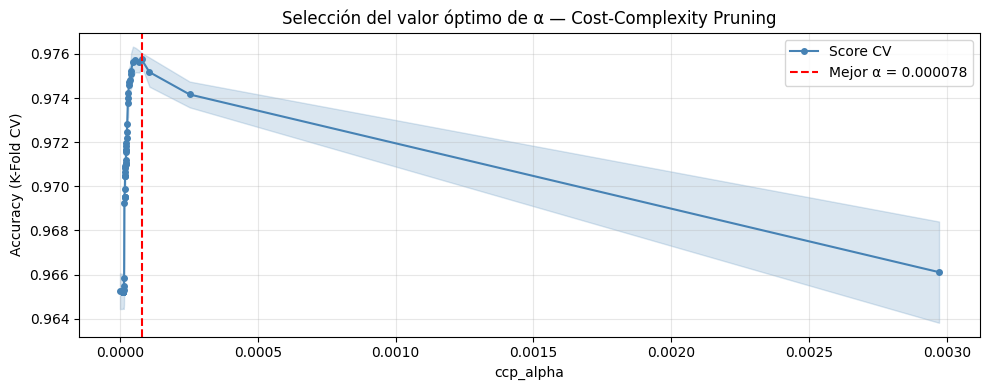

In [ ]:
# ── Gráfica alpha vs accuracy ──────────────────────────────
alphas_p, scores_p, stds_p = zip(*resultados)

plt.figure(figsize=(10, 4))
plt.plot(alphas_p, scores_p, marker='o', markersize=4, color='steelblue', label='Score CV')
plt.fill_between(alphas_p,
                 [s - e for s, e in zip(scores_p, stds_p)],
                 [s + e for s, e in zip(scores_p, stds_p)],
                 alpha=0.2, color='steelblue')
plt.axvline(x=mejor_alpha, color='red', linestyle='--',
            label=f'Mejor α = {mejor_alpha:.6f}')
plt.xlabel('ccp_alpha')
plt.ylabel('Accuracy (K-Fold CV)')
plt.title('Selección del valor óptimo de α — Cost-Complexity Pruning')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<p>
  Por si existieran dudas, la gráfica de alphas efectivos confirma visualmente
  la elección de <strong>α = 0.000078</strong> — línea roja punteada — como punto
  óptimo donde el accuracy alcanza su máximo de <strong>0.9757</strong>.
  A partir de ahí, conforme α crece el árbol se poda más agresivamente y el
  accuracy cae de forma sostenida. La <strong>banda azul estrecha</strong>
  indica que el modelo es estable y consistente entre los 5 folds,
  validando que este α representa el equilibrio ideal entre
  <strong>complejidad y generalización</strong>.
</p>

In [ ]:
# ── Entrenar árbol final con mejor alpha ───────────────────
clf_final = DecisionTreeClassifier(random_state=42, ccp_alpha=mejor_alpha)
clf_final.fit(X_train, y_train)

print(f'Profundidad del árbol podado : {clf_final.get_depth()}')
print(f'Número de hojas              : {clf_final.get_n_leaves()}')
print(f'Número de nodos              : {clf_final.tree_.node_count}')

Profundidad del árbol podado : 12
Número de hojas              : 68
Número de nodos              : 135


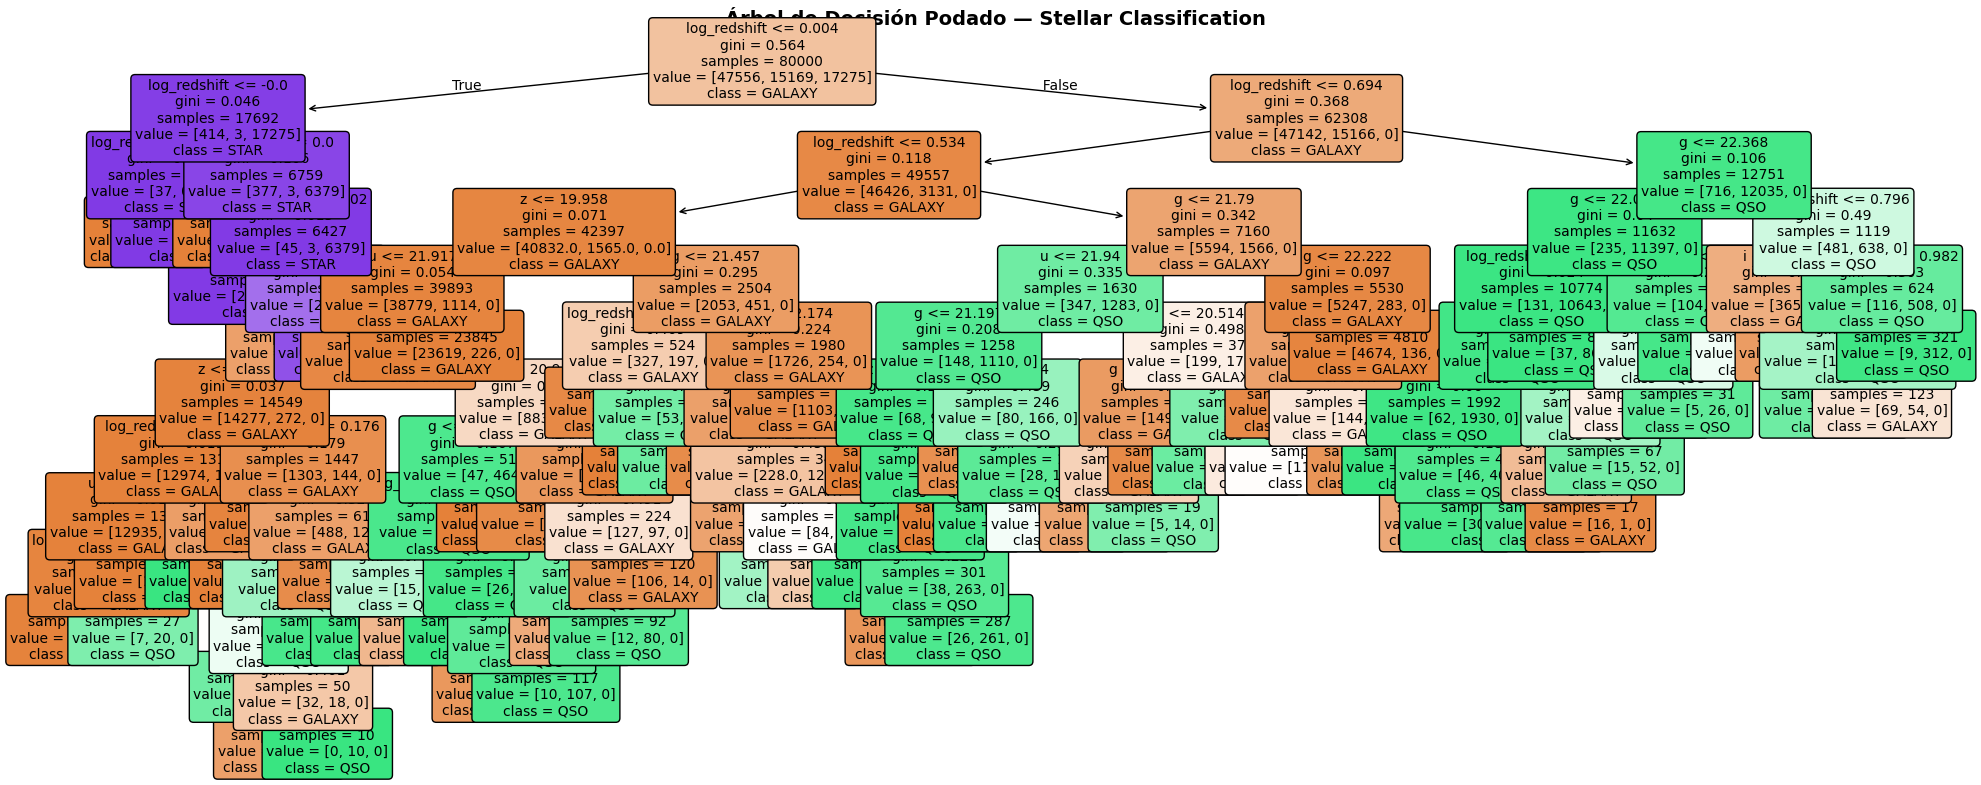

In [ ]:
# ── Visualización del árbol podado ─────────────────────────
plt.figure(figsize=(20, 8))
plot_tree(clf_final,
          feature_names=FEATURES,
          class_names=clf_final.classes_,
          filled=True,
          rounded=True,
          fontsize=10)
plt.title('Árbol de Decisión Podado — Stellar Classification', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

<p>
  Una ventaja clave del árbol de decisión sobre LDA es que nos dice explícitamente
  <strong>qué variables importan más</strong> mediante el índice <em>Gini</em>.
  La gráfica lo confirma: <code>log_redshift</code> domina con una importancia de
  <strong>0.93</strong> — tiene sentido físicamente, ya que es la firma más
  distintiva entre estrellas (redshift ≈ 0), galaxias (valores intermedios) y
  quásares (valores altos). Los filtros espectrales actúan únicamente como
  <strong>refinamiento secundario</strong>. Más allá de esta actividad, este
  resultado es valioso porque <strong>confirma empíricamente</strong> qué variables
  son realmente aportativas — información directamente útil para alimentar modelos
  más robustos como <em>Random Forest</em> o <em>XGBoost</em> que requieren
  una selección cuidadosa de variables de entrada.
</p>

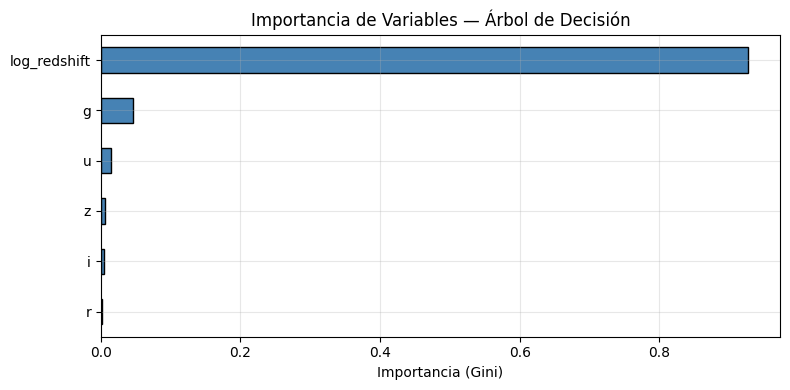


Importancia de variables:
log_redshift    0.9265
g               0.0462
u               0.0151
z               0.0053
i               0.0050
r               0.0019
dtype: float64


In [ ]:
# ── Importancia de variables ───────────────────────────────
importancias = pd.Series(clf_final.feature_importances_, index=FEATURES).sort_values(ascending=True)

plt.figure(figsize=(8, 4))
importancias.plot(kind='barh', color='steelblue', edgecolor='black')
plt.xlabel('Importancia (Gini)')
plt.title('Importancia de Variables — Árbol de Decisión')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('\nImportancia de variables:')
print(importancias.sort_values(ascending=False).round(4))

<h2>Inciso 5: Evaluación y Comparación de Modelos</h2>

<p>
  Con ambos modelos entrenados, se evalúa su desempeño sobre los datos de
  <strong>prueba</strong> — datos que ningún modelo vio durante el entrenamiento.
  Las métricas utilizadas son:
</p>

<ul>
  <li><strong>Accuracy:</strong> proporción de predicciones correctas sobre el total.</li>
  <li><strong>Precision:</strong> de los objetos clasificados como clase \(k\), ¿cuántos realmente lo son?</li>
  <li><strong>Recall:</strong> de los objetos que realmente son clase \(k\), ¿cuántos detectó el modelo?</li>
  <li><strong>F1-score:</strong> media armónica entre precision y recall — \(F1 = 2 \cdot \frac{P \cdot R}{P + R}\)</li>
</ul>

<p>
  Adicionalmente se presentan las <strong>matrices de confusión</strong> de ambos modelos,
  que permiten identificar qué clases se confunden entre sí, y una
  <strong>gráfica comparativa</strong> de todas las métricas para facilitar la
  conclusión sobre cuál modelo es más adecuado para la clasificación de objetos celestes.
</p>

In [ ]:
# ── Predicciones ──────────────────────────────────────────
y_pred_lda  = lda.predict(X_test)
y_pred_tree = clf_final.predict(X_test)

# ── Métricas LDA ──────────────────────────────────────────
print('='*55)
print('RESULTADOS — LDA')
print('='*55)
print(f'Accuracy : {accuracy_score(y_test, y_pred_lda):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_lda, average="weighted"):.4f}')
print(f'Recall   : {recall_score(y_test, y_pred_lda, average="weighted"):.4f}')
print(f'F1-score : {f1_score(y_test, y_pred_lda, average="weighted"):.4f}')
print('\nReporte completo:')
print(classification_report(y_test, y_pred_lda))

# ── Métricas Árbol ─────────────────────────────────────────
print('='*55)
print('RESULTADOS — ÁRBOL DE DECISIÓN')
print('='*55)
print(f'Accuracy : {accuracy_score(y_test, y_pred_tree):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_tree, average="weighted"):.4f}')
print(f'Recall   : {recall_score(y_test, y_pred_tree, average="weighted"):.4f}')
print(f'F1-score : {f1_score(y_test, y_pred_tree, average="weighted"):.4f}')
print('\nReporte completo:')
print(classification_report(y_test, y_pred_tree))

RESULTADOS — LDA
Accuracy : 0.8862
Precision: 0.8876
Recall   : 0.8862
F1-score : 0.8844

Reporte completo:
              precision    recall  f1-score   support

      GALAXY       0.87      0.95      0.91     11889
         QSO       0.96      0.86      0.91      3792
        STAR       0.87      0.74      0.80      4319

    accuracy                           0.89     20000
   macro avg       0.90      0.85      0.87     20000
weighted avg       0.89      0.89      0.88     20000

RESULTADOS — ÁRBOL DE DECISIÓN
Accuracy : 0.9768
Precision: 0.9766
Recall   : 0.9768
F1-score : 0.9766

Reporte completo:
              precision    recall  f1-score   support

      GALAXY       0.97      0.99      0.98     11889
         QSO       0.96      0.92      0.94      3792
        STAR       1.00      1.00      1.00      4319

    accuracy                           0.98     20000
   macro avg       0.98      0.97      0.97     20000
weighted avg       0.98      0.98      0.98     20000



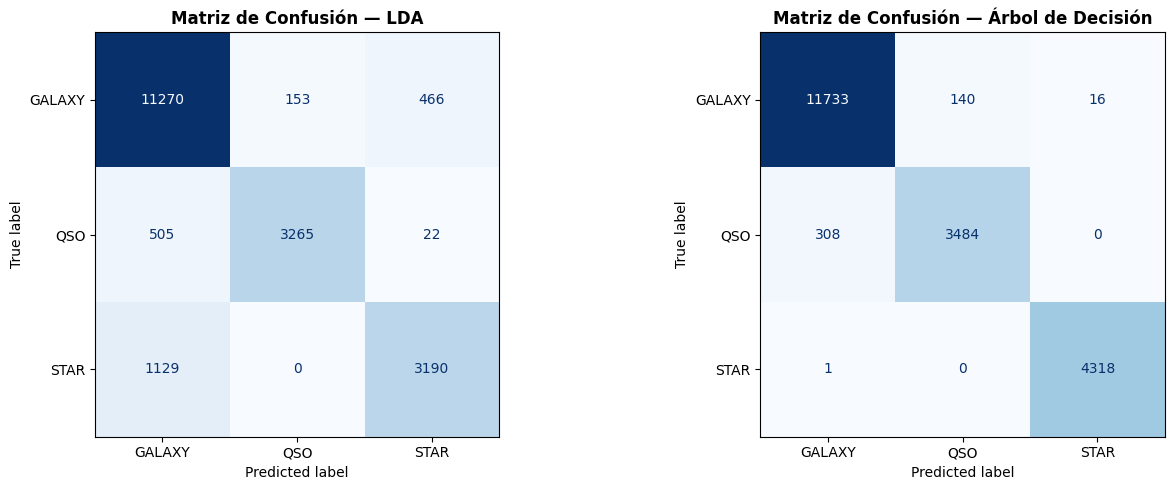

In [ ]:
# ── Matrices de confusión ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_pred, titulo in zip(axes,
                               [y_pred_lda, y_pred_tree],
                               ['LDA', 'Árbol de Decisión']):
    cm = confusion_matrix(y_test, y_pred, labels=clf_final.classes_)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=clf_final.classes_)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Matriz de Confusión — {titulo}', fontweight='bold')

plt.tight_layout()
plt.show()


── Comparación final de modelos ─────────────────────
                   Accuracy  Precision  Recall  F1-score
Modelo                                                  
LDA                  0.8862     0.8876  0.8862    0.8844
Árbol de Decisión    0.9768     0.9766  0.9768    0.9766


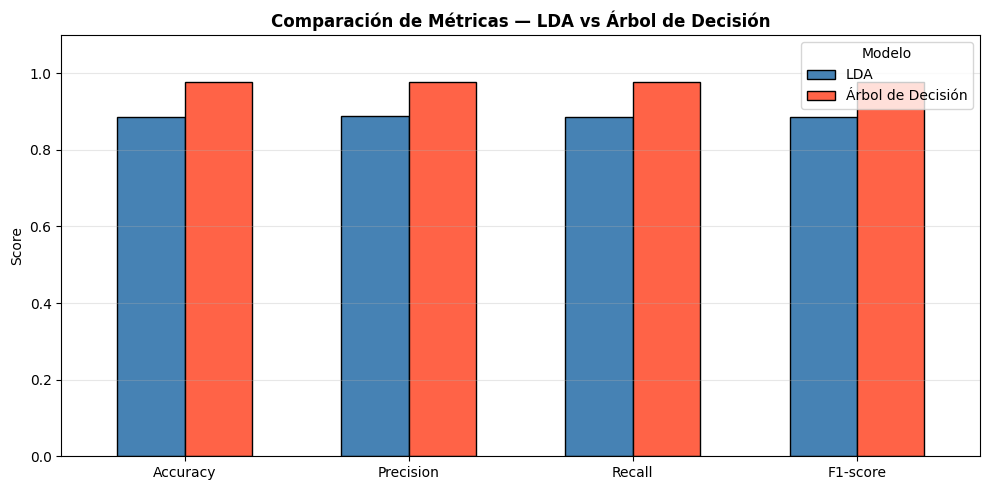

In [ ]:
# ── Tabla comparativa final ────────────────────────────────
metricas = {
    'Modelo'   : ['LDA', 'Árbol de Decisión'],
    'Accuracy' : [accuracy_score(y_test, y_pred_lda),
                  accuracy_score(y_test, y_pred_tree)],
    'Precision': [precision_score(y_test, y_pred_lda, average='weighted'),
                  precision_score(y_test, y_pred_tree, average='weighted')],
    'Recall'   : [recall_score(y_test, y_pred_lda, average='weighted'),
                  recall_score(y_test, y_pred_tree, average='weighted')],
    'F1-score' : [f1_score(y_test, y_pred_lda, average='weighted'),
                  f1_score(y_test, y_pred_tree, average='weighted')]
}

tabla = pd.DataFrame(metricas).set_index('Modelo').round(4)
print('\n── Comparación final de modelos ─────────────────────')
print(tabla.to_string())

# Gráfica comparativa
tabla.T.plot(kind='bar', figsize=(10, 5), color=['steelblue', 'tomato'],
             edgecolor='black', width=0.6)
plt.title('Comparación de Métricas — LDA vs Árbol de Decisión', fontweight='bold')
plt.ylabel('Score')
plt.ylim(0, 1.1)
plt.xticks(rotation=0)
plt.legend(title='Modelo')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

<h2>Conclusión General</h2>

<p>
  ¿Recuerdas cuando al inicio nos preguntamos cómo distinguir un simple punto de luz
  en el cielo — si era una estrella a 500 años luz o un quásar a 13 mil millones de
  años luz? Pues bien, acabamos de responder esa pregunta con <strong>97.68% de
  precisión</strong>. A lo largo de este análisis aplicamos dos modelos sobre el mismo
  dataset astronómico del SDSS DR17, y cada etapa aportó evidencia que apuntó hacia
  la misma dirección. El <strong>LDA</strong>, a pesar de sus limitaciones —
  la homocedasticidad no se cumple porque pedirle la misma varianza a una estrella
  y a un quásar es como pedirle a un foco y a una explosión nuclear que brillen igual —
  logró un respetable <strong>88.6% de accuracy</strong>, justificado por el
  <strong>Teorema Central del Límite</strong> gracias a nuestras más de 15,000
  observaciones por clase. El <strong>árbol de decisión podado</strong>, en cambio,
  no necesitó asumir nada — simplemente aprendió que si <code>log_redshift ≈ 0</code>
  es una estrella, si es alto es un quásar, y lo que queda es una galaxia,
  con una elegancia matemática que se tradujo en <strong>F1 perfecto de 1.00
  para estrellas</strong> y <strong>~9 puntos porcentuales de ventaja</strong>
  sobre LDA en todas las métricas. La conclusión es clara: el árbol de decisión
  es el modelo más adecuado para esta tarea — respaldado por evidencia cuantitativa,
  cualitativa y por la literatura
  <a href="https://www.aanda.org/articles/aa/full_html/2020/07/aa36770-19/aa36770-19.html"
  target="_blank">(Clarke et al., 2020)</a>.
  Y lo más emocionante de todo: acabamos de construir, con matemáticas y datos reales
  del universo, una pequeña pieza de lo que proyectos como el
  <a href="https://www.lsst.org" target="_blank">LSST</a> necesitarán para catalogar
  <strong>40,000 millones de objetos celestes</strong> en la próxima década.

</p>